# Boston Housing Price Prediction using deployed model in watsonx.ai 

This notebook demonstrates how to call a deployed watson.ai model for Boston Housing price predictions.

## Dataset Features
- **CRIM**: Per capita crime rate by town
- **ZN**: Proportion of residential land zoned for lots over 25,000 sq.ft.
- **INDUS**: Proportion of non-retail business acres per town
- **CHAS**: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- **NOX**: Nitric oxides concentration (parts per 10 million)
- **RM**: Average number of rooms per dwelling
- **AGE**: Proportion of owner-occupied units built prior to 1940
- **DIS**: Weighted distances to five Boston employment centres
- **RAD**: Index of accessibility to radial highways
- **TAX**: Full-value property-tax rate per $10,000
- **PTRATIO**: Pupil-teacher ratio by town
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town
- **LSTAT**: % lower status of the population
- **MEDV**: Median value of owner-occupied homes in $1000's (target variable)

## 1. Install Required Libraries

In [24]:
# Install required packages if not already installed
!uv pip install "numpy<2.0.0" pandas matplotlib requests ibm-watson-machine-learning

Using Python 3.12.11 environment at: /Users/gary/Documents/Demos/IFSA-students/.venv
Audited 5 packages in 22ms


## 2. Import Libraries

In [25]:
import requests
import json
import pandas as pd
import numpy as np
from typing import List, Dict, Any

## 3. Configuration

**Important**: You need to provide your Watson Machine Learning credentials:
- API Key
- IBM Cloud IAM Token (or the script will generate one from your API key)

In [26]:
# Watson Machine Learning Configuration
WML_DEPLOYMENT_URL = "https://us-south.ml.cloud.ibm.com/ml/v4/deployments/house_market_prediction/predictions?version=2021-05-01" # YOUR ENDPOINT

# IBM Cloud Authentication
import getpass
IBM_CLOUD_API_KEY = getpass.getpass("Enter your API key here.")  # Replace with your actual API key


# Feature names in the correct order
FEATURE_NAMES = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

## 4. Authentication Helper Functions

In [27]:
def get_iam_token(api_key: str) -> str:
    """
    Generate an IAM token from IBM Cloud API key.
    
    Args:
        api_key: IBM Cloud API key
        
    Returns:
        IAM access token
    """
    url = "https://iam.cloud.ibm.com/identity/token"
    headers = {
        "Content-Type": "application/x-www-form-urlencoded"
    }
    data = {
        "grant_type": "urn:ibm:params:oauth:grant-type:apikey",
        "apikey": api_key
    }
    
    response = requests.post(url, headers=headers, data=data)
    
    if response.status_code == 200:
        return response.json()["access_token"]
    else:
        raise Exception(f"Failed to get IAM token: {response.status_code} - {response.text}")


def get_auth_token() -> str:
    """
    Get authentication token (either from provided token or generate from API key).
    
    Returns:
        Authentication token
    """
    global IBM_CLOUD_API_KEY
    if IBM_CLOUD_API_KEY:
        print("Generating IAM token from API key...")
        return get_iam_token(IBM_CLOUD_API_KEY)
    else:
        raise ValueError("Please provide either IBM_CLOUD_API_KEY or IAM_TOKEN")

## 5. Prediction Function

In [39]:
def predict_house_price(input_data: List[List[float]], feature_names: List[str] = None) -> Dict[str, Any]:
    """
    Make predictions using the Watson ML deployment endpoint.
    
    Args:
        input_data: List of feature vectors (each vector is a list of 13 features)
        feature_names: Optional list of feature names
        
    Returns:
        Dictionary containing predictions and metadata
    """
    # Get authentication token
    token = get_auth_token()
    
    # Prepare headers
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token}"
    }
    
    # Prepare payload
    payload = {
        "input_data": [
            {
                "fields": feature_names if feature_names else FEATURE_NAMES,
                "values": input_data
            }
        ]
    }
    
    # Make prediction request
    print(f"Sending prediction request for {len(input_data)} sample(s)...")
    response = requests.post(WML_DEPLOYMENT_URL, headers=headers, json=payload)
    
    if response.status_code == 200:
        result = response.json()
        print("✓ Prediction successful!")
        return result
    else:
        raise Exception(f"Prediction failed: {response.status_code} - {response.text}")


def extract_predictions(response: Dict[str, Any]) -> List[float]:
    """
    Extract prediction values from the API response.
    
    Args:
        response: API response dictionary
        
    Returns:
        List of predicted values
    """
    try:
        predictions = response['predictions'][0]['values']
        # Extract the predicted value (usually the first or last column)
        return [pred[-1] if isinstance(pred, list) else pred for pred in predictions]
    except (KeyError, IndexError) as e:
        print(f"Warning: Could not extract predictions in expected format: {e}")
        return response

## 6. Load Sample Data

In [ ]:
# If run locally, uncomment following line and skip next cell
# df = pd.read_csv('../data/HousingData_test.csv')

In [ ]:
# LOAD TEST DATASET FROM S3 BUCKET IN WATSONX.AI notebook
# STEPS:
#  1. Click the "</> Code Snippets" button in the top right corner
#  2. Select "Read data" in Data Ingestion part
#  3. Select data from project -> Data asset -> HousingData_test.csv
#  4. Click "Insert code to cell"
#  5. Run cell

# Following code with all credentials should appear:
# import os, types
# import pandas as pd
# from botocore.client import Config
# import ibm_boto3

# def __iter__(self): return 0

# # @hidden_cell
# # The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# # You might want to remove those credentials before you share the notebook.

# cos_client = ibm_boto3.client(service_name='s3',
#     ibm_api_key_id='#####',
#     ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
#     config=Config(signature_version='oauth'),
#     endpoint_url='#####')

# bucket = '#####'
# object_key = 'HousingData_train.csv'

# body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# # add missing __iter__ method, so pandas accepts body as file-like object
# if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

# df_1 = pd.read_csv(body)
# df_1.head(10)


In [ ]:
df = df_1.copy()

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nDataset info:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

Dataset shape: (51, 14)

First few rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.09178,0.0,NaN,0.0,0.510,6.416,NaN,2.6463,5,296,16.6,395.50,9.04,23.6
1,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53,32.4
2,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07,13.6
3,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52,22.8
4,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27,16.1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     51 non-null     float64
 1   ZN       49 non-null     float64
 2   INDUS    50 non-null     float64
 3   CHAS     49 non-null     float64
 4   NOX      51 non-null     float64
 5   RM       51 non-null     float64
 6   AGE      49 non-null     float64
 7   DIS      51 non-null     float64
 8   RAD      51 non-null     int64  
 9   TAX      51 non-null     int64  
 10  PTRATIO  51 non-null     float64
 11  B        51 non-null     float64
 12  LSTAT    46 non-null     float64
 13  MEDV     51 non-null     float64
dtypes: float64(12), int64(2)
memory usage: 5.7 KB


None


Missing values:


CRIM       0
ZN         2
INDUS      1
CHAS       2
NOX        0
RM         0
AGE        2
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      5
MEDV       0
dtype: int64

## 7. Prepare Test Data

Handle missing values and prepare features for prediction.

In [31]:
# Separate features and target
X = df[FEATURE_NAMES].copy()
y = df['MEDV'].copy() if 'MEDV' in df.columns else None

# Handle missing values - fill with median
X_filled = X.fillna(X.median())

print("Features after handling missing values:")
display(X_filled.head())
print("\nRemaining missing values:", X_filled.isnull().sum().sum())

Features after handling missing values:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.09178,0.0,10.81,0.0,0.510,6.416,79.7,2.6463,5,296,16.6,395.50,9.04
1,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
2,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
3,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
4,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27



Remaining missing values: 0


## 8. Example 1: Single Prediction

Make a prediction for a single house.

In [32]:
# Select first row as example
sample_input = X_filled.iloc[0:1].values.tolist()

print("Input features:")
for name, value in zip(FEATURE_NAMES, sample_input[0]):
    print(f"  {name}: {value}")

# Make prediction
try:
    response = predict_house_price(sample_input)
    predictions = extract_predictions(response)
    
    print(f"\n{'='*50}")
    print(f"Predicted house price: ${predictions[0]:.2f}k")
    
    if y is not None:
        actual = y.iloc[0]
        print(f"Actual house price: ${actual:.2f}k")
        print(f"Difference: ${abs(predictions[0] - actual):.2f}k")
    print(f"{'='*50}")
    
except Exception as e:
    print(f"Error: {e}")

Input features:
  CRIM: 0.09178
  ZN: 0.0
  INDUS: 10.81
  CHAS: 0.0
  NOX: 0.51
  RM: 6.416
  AGE: 79.7
  DIS: 2.6463
  RAD: 5.0
  TAX: 296.0
  PTRATIO: 16.6
  B: 395.5
  LSTAT: 9.04
Generating IAM token from API key...
Sending prediction request for 1 sample(s)...
✓ Prediction successful!

Predicted house price: $24.50k
Actual house price: $23.60k
Difference: $0.90k


## 9. Example 2: Batch Predictions

Make predictions for multiple houses at once.

In [33]:
# Select first 5 rows for batch prediction
batch_input = X_filled.iloc[0:5].values.tolist()

print(f"Making predictions for {len(batch_input)} houses...\n")

try:
    response = predict_house_price(batch_input)
    predictions = extract_predictions(response)
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Predicted_Price_k': predictions
    })
    
    if y is not None:
        results_df['Actual_Price_k'] = y.iloc[0:5].values
        results_df['Difference_k'] = abs(results_df['Predicted_Price_k'] - results_df['Actual_Price_k'])
    
    print("\nPrediction Results:")
    display(results_df)
    
    if y is not None:
        mae = results_df['Difference_k'].mean()
        print(f"\nMean Absolute Error: ${mae:.2f}k")
    
except Exception as e:
    print(f"Error: {e}")

Making predictions for 5 houses...

Generating IAM token from API key...
Sending prediction request for 5 sample(s)...
✓ Prediction successful!

Prediction Results:


,Predicted_Price_k,Actual_Price_k,Difference_k
0,24.500820,23.6,0.900820
1,32.365955,32.4,0.034045
2,14.253352,13.6,0.653352
3,22.946085,22.8,0.146085
4,17.035922,16.1,0.935922



Mean Absolute Error: $0.53k


## 10. Example 3: Custom Input

Create your own input data for prediction.

In [40]:
# Create custom input (example values)
custom_input = [[
    0.00632,  # CRIM: Crime rate
    18.0,     # ZN: Residential land zoned
    2.31,     # INDUS: Non-retail business acres
    0,        # CHAS: Charles River (0 or 1)
    0.538,    # NOX: Nitric oxides concentration
    6.575,    # RM: Average rooms per dwelling
    65.2,     # AGE: Proportion of old units
    4.09,     # DIS: Distance to employment centers
    1,        # RAD: Highway accessibility index
    296,      # TAX: Property tax rate
    15.3,     # PTRATIO: Pupil-teacher ratio
    396.9,    # B: Proportion of Black residents
    4.98      # LSTAT: Lower status population %
]]

print("Custom input features:")
for name, value in zip(FEATURE_NAMES, custom_input[0]):
    print(f"  {name}: {value}")

try:
    response = predict_house_price(custom_input)
    predictions = extract_predictions(response)
    
    print(f"\n{'='*50}")
    print(f"Predicted house price: ${predictions[0]:.2f}k")
    print(f"{'='*50}")
    
except Exception as e:
    print(f"Error: {e}")

Custom input features:
  CRIM: 0.00632
  ZN: 18.0
  INDUS: 2.31
  CHAS: 0
  NOX: 0.538
  RM: 6.575
  AGE: 65.2
  DIS: 4.09
  RAD: 1
  TAX: 296
  PTRATIO: 15.3
  B: 396.9
  LSTAT: 4.98
Generating IAM token from API key...
Sending prediction request for 1 sample(s)...
✓ Prediction successful!

Predicted house price: $28.68k


## 11. Visualize Predictions vs Actual (Optional)

Compare predictions with actual values for a larger sample.

Generating IAM token from API key...
Sending prediction request for 20 sample(s)...
✓ Prediction successful!


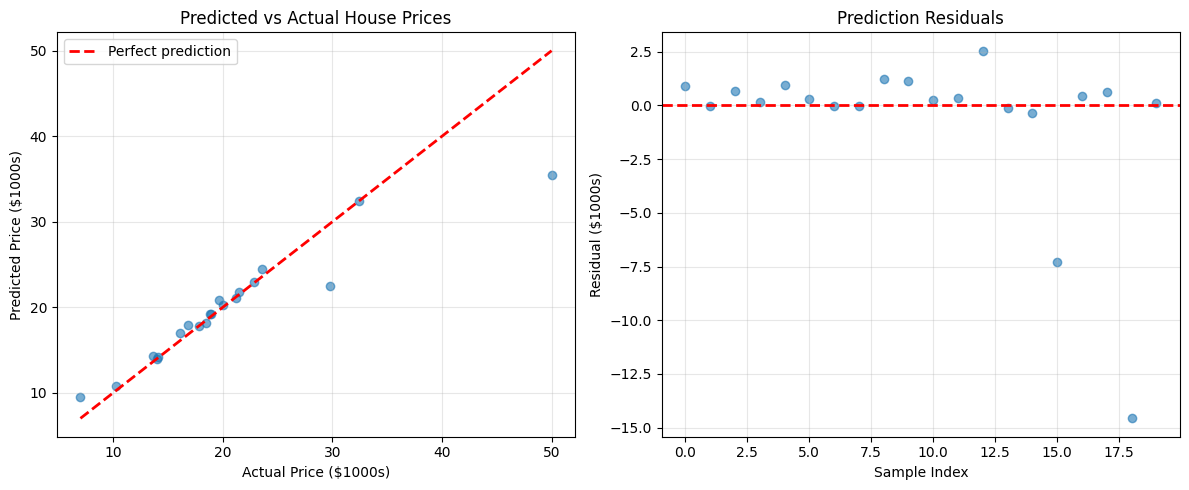


Prediction Statistics:
  Mean Absolute Error: $1.60k
  Root Mean Squared Error: $3.72k


In [35]:
import matplotlib.pyplot as plt

# Make predictions for first 20 samples
n_samples = min(20, len(X_filled))
test_input = X_filled.iloc[0:n_samples].values.tolist()

try:
    response = predict_house_price(test_input)
    predictions = extract_predictions(response)
    
    if y is not None:
        actual_values = y.iloc[0:n_samples].values
        
        # Create visualization
        plt.figure(figsize=(12, 5))
        
        # Plot 1: Predictions vs Actual
        plt.subplot(1, 2, 1)
        plt.scatter(actual_values, predictions, alpha=0.6)
        plt.plot([actual_values.min(), actual_values.max()], 
                [actual_values.min(), actual_values.max()], 
                'r--', lw=2, label='Perfect prediction')
        plt.xlabel('Actual Price ($1000s)')
        plt.ylabel('Predicted Price ($1000s)')
        plt.title('Predicted vs Actual House Prices')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        plt.subplot(1, 2, 2)
        residuals = np.array(predictions) - actual_values
        plt.scatter(range(len(residuals)), residuals, alpha=0.6)
        plt.axhline(y=0, color='r', linestyle='--', lw=2)
        plt.xlabel('Sample Index')
        plt.ylabel('Residual ($1000s)')
        plt.title('Prediction Residuals')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        mae = np.mean(np.abs(residuals))
        rmse = np.sqrt(np.mean(residuals**2))
        print(f"\nPrediction Statistics:")
        print(f"  Mean Absolute Error: ${mae:.2f}k")
        print(f"  Root Mean Squared Error: ${rmse:.2f}k")
    else:
        print("No actual values available for comparison")
        
except Exception as e:
    print(f"Error: {e}")

## 12. Summary

This notebook demonstrates:
1. Authentication with IBM watsonx.ai
2. Making single and batch predictions
3. Handling missing values in input data
4. Comparing predictions with actual values
5. Visualizing model performance

### Next Steps:
- Experiment with different input values
- Analyze feature importance
- Test edge cases and data quality
- Integrate predictions into your application